<a href="https://colab.research.google.com/github/Jocarchi/TFG/blob/main/TFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Codigo base


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ==============================================================================
# 1. CLASE MAESTRA: SOLUCIONADOR AUTÓNOMO PL
# ==============================================================================
class SolucionadorAutonomoPL:
    def __init__(self, tabla_original, nombres_cols, tipo_problema="min", paso_a_paso=False, solo_resumen=False):
        self.tabla = np.array(tabla_original, dtype=float)
        self.tabla_original = np.array(tabla_original, dtype=float)
        self.nombres_cols = nombres_cols[:]
        self.nombres_cols_originales = nombres_cols[:]
        self.tipo_problema = tipo_problema.lower()
        self.num_filas, self.num_cols = self.tabla.shape
        self.vars_basicas = [""] * (self.num_filas - 1)
        self.vars_artificiales = []
        self.f0_original = None
        self.solucion_encontrada = False

        # Rastrear las filas (restricciones) originales que sobreviven a la fase 1
        self.filas_originales_validas = list(range(1, self.num_filas))

        # Control de visualización
        self.paso_a_paso = paso_a_paso
        self.solo_resumen = solo_resumen

    def log(self, mensaje):
        """Imprime mensajes solo si no estamos en el modo 'Solo Resumen'."""
        if not self.solo_resumen:
            print(mensaje)

    def get_idx_vars(self):
        return [i for i, c in enumerate(self.nombres_cols) if c.lower() not in ['z', 'rhs']]

    def mostrar_tabla(self, titulo=""):
        if self.solo_resumen:
            return

        print(f"\n--- TABLA {titulo} ---")
        encabezado = "Base\t" + "\t".join(self.nombres_cols)
        print(encabezado)
        for i in range(self.num_filas):
            base_nombre = "Z" if i == 0 else self.vars_basicas[i-1]
            fila = "\t".join([f"{val:6.2f}" for val in self.tabla[i]])
            print(f"{base_nombre}\t{fila}")
        print("-" * 65)

        if self.paso_a_paso:
            input(" ⏳ Presiona [ENTER] para continuar al siguiente paso...")

    def diagnosticar_estado(self):
        rhs = self.tabla[1:, -1]
        idx_vars = self.get_idx_vars()
        costos = self.tabla[0, idx_vars]

        es_factible = np.all(rhs >= -1e-5)
        if self.tipo_problema == "max":
            es_optima = np.all(costos >= -1e-5)
        else:
            es_optima = np.all(costos <= 1e-5)
        return es_factible, es_optima

    def pivotar(self, fila, col):
        pivot = self.tabla[fila, col]
        self.log(f" PIVOTANDO: Sale [{self.vars_basicas[fila-1]}] y Entra [{self.nombres_cols[col]}] | Elemento Pivote: {pivot:.2f}")
        self.tabla[fila, :] = self.tabla[fila, :] / pivot
        for i in range(self.num_filas):
            if i != fila:
                multiplicador = self.tabla[i, col]
                self.tabla[i, :] -= multiplicador * self.tabla[fila, :]
        self.vars_basicas[fila - 1] = self.nombres_cols[col]

    def preparar_bases_o_dos_fases(self):
        self.log("  ANALIZANDO LA MATRIZ INICIAL...")
        necesita_dos_fases = False
        filas_sin_base = []

        es_factible, es_optima = self.diagnosticar_estado()
        aplicar_dual = es_optima and not es_factible

        for i in range(1, self.num_filas):
            if self.tabla[i, -1] < 0 and not aplicar_dual:
                self.tabla[i, :] *= -1
                self.log(f"   [!] Fila {i} multiplicada por -1 para recuperar RHS >= 0.")

        idx_vars = self.get_idx_vars()
        for i in range(1, self.num_filas):
            tiene_base = False
            for j in idx_vars:
                columna = self.tabla[1:, j]
                if abs(self.tabla[i, j] - 1.0) < 1e-5 and np.sum(np.abs(columna)) == 1.0:
                    self.vars_basicas[i-1] = self.nombres_cols[j]
                    tiene_base = True
                    break

            if not tiene_base:
                filas_sin_base.append(i)
                necesita_dos_fases = True

        if necesita_dos_fases and aplicar_dual:
             aplicar_dual = False

        if necesita_dos_fases and not aplicar_dual:
            self.log(f"   [!] Faltan variables básicas en las filas: {filas_sin_base}. Iniciando DOS FASES.")
            self.f0_original = self.tabla[0, :].copy()

            num_artificiales = len(filas_sin_base)
            nueva_tabla = np.zeros((self.num_filas, self.num_cols + num_artificiales))
            nueva_tabla[:, :self.num_cols-1] = self.tabla[:, :-1]
            nueva_tabla[:, -1] = self.tabla[:, -1]
            nueva_tabla[0, :] = 0.0

            idx_art = self.num_cols - 1
            for fila_idx in filas_sin_base:
                nombre_art = f"A{fila_idx}"
                self.nombres_cols.insert(idx_art, nombre_art)
                self.vars_artificiales.append(nombre_art)
                self.vars_basicas[fila_idx-1] = nombre_art
                nueva_tabla[fila_idx, idx_art] = 1.0
                nueva_tabla[0, idx_art] = -1.0
                nueva_tabla[0, :] += nueva_tabla[fila_idx, :]
                idx_art += 1

            self.tabla = nueva_tabla
            self.num_cols = self.tabla.shape[1]
            self.tipo_problema_original = self.tipo_problema
            self.tipo_problema = "min"

        return necesita_dos_fases, aplicar_dual

    def iterar_simplex(self, es_fase1=False):
        while True:
            es_factible, es_optima = self.diagnosticar_estado()
            idx_vars = self.get_idx_vars()

            if es_factible and es_optima:
                return True

            elif es_factible and not es_optima:
                costos = self.tabla[0, idx_vars]
                idx_relativo = np.argmin(costos) if self.tipo_problema == "max" else np.argmax(costos)
                col_entrada = idx_vars[idx_relativo]

                ratios = []
                for i in range(1, self.num_filas):
                    coef = self.tabla[i, col_entrada]
                    ratios.append(self.tabla[i, -1] / coef if coef > 1e-5 else np.inf)
                if all(r == np.inf for r in ratios):
                    self.log(" PROBLEMA NO ACOTADO.")
                    return False
                fila_salida = np.argmin(ratios) + 1
                self.pivotar(fila_salida, col_entrada)
                self.mostrar_tabla("FASE I (Iteración)" if es_fase1 else "FASE II (Iteración)")

            elif not es_factible and es_optima:
                self.log(" Aplicando iteración de SIMPLEX DUAL")
                rhs = self.tabla[1:, -1]
                fila_salida = np.argmin(rhs) + 1

                costos = self.tabla[0, idx_vars]
                coeficientes = self.tabla[fila_salida, idx_vars]

                ratios = []
                for j, coef in enumerate(coeficientes):
                    if coef < -1e-5:
                        ratios.append(abs(costos[j] / coef))
                    else:
                        ratios.append(np.inf)

                if all(r == np.inf for r in ratios):
                    self.log(" PROBLEMA IMPOSSIBLE (Infactible).")
                    return False
                idx_relativo = np.argmin(ratios)
                col_entrada = idx_vars[idx_relativo]
                self.pivotar(fila_salida, col_entrada)
                self.mostrar_tabla("DUAL SIMPLEX (Iteración)")

            else:
                self.log(" ESTADO BLOQUEADO: Posible ciclo o fallo de matriz.")
                return False

    def transicion_fase_2(self):
        self.log("\n" + "*"*50)
        self.log("  FASE I COMPLETADA. PREPARANDO FASE II...")
        self.log("*"*50)

        filas_redundantes = []
        for i, var in enumerate(self.vars_basicas):
            if var in self.vars_artificiales:
                filas_redundantes.append(i + 1)

        if not self.solo_resumen:
            print("\n" + "="*70)
            print(" 🔍 ANÁLISIS DE INDEPENDENCIA LINEAL (Teoría Simplex)")
            print("="*70)

        if filas_redundantes:
            idx_reales = [j for j, col in enumerate(self.nombres_cols_originales)
                          if not re.match(r'^[he]\d+$', col) and col.lower() not in ['z', 'rhs']]
            idx_reales.append(-1)
            A_espacial = self.tabla_original[1:, idx_reales]

            for i, var in enumerate(self.vars_basicas):
                if var in self.vars_artificiales:
                    try: fila_orig_idx = int(var.replace('A', ''))
                    except ValueError: fila_orig_idx = i + 1

                    self.log(f"\n [!] Detección: La Restricción {fila_orig_idx} es REDUNDANTE.")
                    idx_target = fila_orig_idx - 1
                    filas_otras_idx = [j for j in range(A_espacial.shape[0]) if j != idx_target]

                    if filas_otras_idx:
                        M_otras = A_espacial[filas_otras_idx, :]
                        y_target = A_espacial[idx_target, :]
                        c, _, _, _ = np.linalg.lstsq(M_otras.T, y_target.T, rcond=None)

                        if np.allclose(np.dot(c, M_otras), y_target, atol=1e-4):
                            explicacion = []
                            for j_idx, coef in enumerate(c):
                                if abs(coef) > 1e-4:
                                    n_rest = filas_otras_idx[j_idx] + 1
                                    explicacion.append(f"{coef:.2f} * (Rest. {n_rest})")
                            eq_str = " + ".join(explicacion).replace("+ -", "- ")
                            self.log(f"     Explicación Geométrica: La Restricción {fila_orig_idx} equivale a: [ {eq_str} ]")

            self.tabla = np.delete(self.tabla, filas_redundantes, axis=0)
            # Actualizamos el trackeo de las filas que sobreviven para reconstruir B^-1 luego
            self.filas_originales_validas = [f for i, f in enumerate(self.filas_originales_validas) if (i + 1) not in filas_redundantes]
            self.num_filas = self.tabla.shape[0]
            self.vars_basicas = [v for i, v in enumerate(self.vars_basicas) if (i + 1) not in filas_redundantes]

        if not self.solo_resumen:
            print("="*70)

        indices_eliminar = [self.nombres_cols.index(v) for v in self.vars_artificiales if v in self.nombres_cols]
        self.tabla = np.delete(self.tabla, indices_eliminar, axis=1)
        self.nombres_cols = [c for c in self.nombres_cols if c not in self.vars_artificiales]
        self.num_cols = self.tabla.shape[1]

        self.tabla[0, :] = 0.0
        for j, nombre in enumerate(self.nombres_cols):
            if nombre in self.nombres_cols_originales:
                idx_orig = self.nombres_cols_originales.index(nombre)
                self.tabla[0, j] = self.f0_original[idx_orig]
        self.tabla[0, -1] = self.f0_original[-1]

        self.tipo_problema = self.tipo_problema_original

        for i in range(1, self.num_filas):
            var_basica = self.vars_basicas[i-1]
            if var_basica in self.nombres_cols:
                col_idx = self.nombres_cols.index(var_basica)
                multiplicador = self.tabla[0, col_idx]
                if abs(multiplicador) > 1e-5:
                    self.tabla[0, :] -= multiplicador * self.tabla[i, :]

    def resolver(self):
        self.solucion_encontrada = False
        necesita_dos_fases, aplicar_dual = self.preparar_bases_o_dos_fases()

        if aplicar_dual:
             self.mostrar_tabla("INICIO DUAL-SIMPLEX")
             exito = self.iterar_simplex()
        else:
            if necesita_dos_fases:
                self.mostrar_tabla("INICIO FASE I")
                exito = self.iterar_simplex(es_fase1=True)
                if not exito: return
                if self.tabla[0, -1] > 1e-5:
                    self.log(" El problema original es INFACTIBLE.")
                    return
                self.transicion_fase_2()
                self.mostrar_tabla("INICIO FASE II")
            else:
                self.mostrar_tabla("INICIAL")
            exito = self.iterar_simplex(es_fase1=False)

        if exito:
            self.solucion_encontrada = True

    # --------------------------------------------------------------------------
    # MÓDULOS TEÓRICOS Y DE SENSIBILIDAD CORREGIDOS MATEMÁTICAMENTE
    # --------------------------------------------------------------------------
    def get_inversa_base(self):
        """Calcula B^-1 directamente usando las columnas originales (método infalible)."""
        num_vars_basicas = len(self.vars_basicas)
        B = np.zeros((num_vars_basicas, num_vars_basicas))
        for j, var in enumerate(self.vars_basicas):
            idx_orig = self.nombres_cols_originales.index(var)
            for local_i, fila_orig in enumerate(self.filas_originales_validas):
                B[local_i, j] = self.tabla_original[fila_orig, idx_orig]
        try:
            return np.linalg.inv(B)
        except np.linalg.LinAlgError:
            return None

    def mostrar_informacion_teorica_final(self):
        if not self.solucion_encontrada: return
        print("\n" + "="*70)
        print(" 📊 ANÁLISIS ESTRUCTURAL ÓPTIMO (Teoría Simplex)")
        print("="*70)

        print(f" [1] Base Óptima (B): {self.vars_basicas}")
        solucion_str = []
        for var in self.nombres_cols_originales:
            if var.lower() not in ['z', 'rhs'] and not var.startswith(('h', 'e', 'A')):
                valor = self.tabla[self.vars_basicas.index(var) + 1, -1] if var in self.vars_basicas else 0.0
                solucion_str.append(f"{var} = {valor:.2f}")
        print(f" [2] Punto Óptimo (x*): ( {', '.join(solucion_str)} )")
        print(f" [3] Valor Objetivo (Z*): {self.tabla[0, -1]:.2f}\n")

        B_inv = self.get_inversa_base()
        if B_inv is not None:
            print(" [4] Matriz Inversa de la Base (B^-1):")
            for fila in B_inv:
                print("     | " + "  ".join([f"{val:6.2f}" for val in fila]) + " |")
        else:
            print(" [4] Matriz Inversa de la Base (B^-1): No calculable (Matriz B singular).")

        print("\n [5] Ecuación de Costes Reducidos (Fila 0):")
        ecuacion_z = [f"Z"]
        for j, col in enumerate(self.nombres_cols):
            coef = self.tabla[0, j]
            if abs(coef) > 1e-5 and col.lower() != 'rhs':
                signo = "+" if coef > 0 else "-"
                ecuacion_z.append(f"{signo} {abs(coef):.2f}{col}")
        print(f"     {' '.join(ecuacion_z)} = {self.tabla[0, -1]:.2f}")
        print("="*70 + "\n")

    def calcular_rangos_sensibilidad(self):
        if not self.solucion_encontrada: return
        print("\n" + "="*80)
        print(" 📈 RANGOS DE TOLERANCIA Y ESTABILIDAD DE LA BASE ÓPTIMA")
        print("="*80)

        num_restricciones = len(self.vars_basicas)
        rhs_actual = self.tabla[1:, -1]
        B_inv = self.get_inversa_base()

        if B_inv is None:
            print(" [!] No es posible calcular rangos de sensibilidad (B^-1 indefinida).")
            return

        print(" [A] Rangos para los Términos Independientes (b_i) [Condición de Factibilidad]:")
        print(f" {'Restricción':<12} | {'Valor Inicial':<15} | {'Valor Mínimo':<15} | {'Valor Máximo':<15}")
        print("-" * 80)
        for local_i, orig_i in enumerate(self.filas_originales_validas):
            b_orig = self.tabla_original[orig_i, -1]
            delta_min, delta_max = -np.inf, np.inf

            for k in range(num_restricciones):
                beta_ki = B_inv[k, local_i]
                b_barra_k = rhs_actual[k]

                # Despeje de b_barra + delta * beta_ki >= 0
                if beta_ki > 1e-5:
                    limite = -b_barra_k / beta_ki
                    if limite > delta_min: delta_min = limite  # Cota inferior
                elif beta_ki < -1e-5:
                    limite = -b_barra_k / beta_ki
                    if limite < delta_max: delta_max = limite  # Cota superior

            val_min = b_orig + delta_min if delta_min != -np.inf else -np.inf
            val_max = b_orig + delta_max if delta_max != np.inf else np.inf
            str_min = f"{val_min:.2f}" if val_min != -np.inf else "-Infinito"
            str_max = f"{val_max:.2f}" if val_max != np.inf else "+Infinito"
            print(f" Rest. {orig_i:<6} | {b_orig:<15.2f} | {str_min:<15} | {str_max:<15}")

        print("\n [B] Rangos para los Coeficientes de la Función Objetivo (c_j) [Condición de Optimalidad]:")
        print(f" {'Variable':<12} | {'Coef. Inicial':<15} | {'Valor Mínimo':<15} | {'Valor Máximo':<15}")
        print("-" * 80)
        vars_decision = [c for c in self.nombres_cols_originales if c.startswith('x')]

        for var in vars_decision:
            idx_orig = self.nombres_cols_originales.index(var)
            c_orig = -self.tabla_original[0, idx_orig]
            if var not in self.nombres_cols: continue
            idx_final = self.nombres_cols.index(var)

            # En fila 0 tenemos T_0j = z_j - c_j
            cj_barra_actual = self.tabla[0, idx_final]

            if var not in self.vars_basicas:
                # Variable no básica: cambiar c_j solo afecta su propio costo reducido.
                if self.tipo_problema == "max":
                    val_min, val_max = -np.inf, c_orig + cj_barra_actual
                else:
                    val_min, val_max = c_orig + cj_barra_actual, np.inf
            else:
                # Variable básica: cambiar su coste arrastra toda la fila 0
                fila_basica = self.vars_basicas.index(var) + 1
                delta_min, delta_max = -np.inf, np.inf

                for j_col, nom_col in enumerate(self.nombres_cols):
                    if nom_col.lower() in ['z', 'rhs'] or nom_col in self.vars_basicas: continue
                    alpha_kj = self.tabla[fila_basica, j_col]
                    T0j = self.tabla[0, j_col]

                    if abs(alpha_kj) > 1e-5:
                        limite = -T0j / alpha_kj
                        if self.tipo_problema == "max":
                            # Nueva T0j = T0j + delta * alpha_kj >= 0  => delta * alpha >= -T0j
                            if alpha_kj > 1e-5:
                                if limite > delta_min: delta_min = limite # Cota inferior
                            else:
                                if limite < delta_max: delta_max = limite # Cota superior
                        else:
                            # Nueva T0j = T0j + delta * alpha_kj <= 0  => delta * alpha <= -T0j
                            if alpha_kj > 1e-5:
                                if limite < delta_max: delta_max = limite # Cota superior
                            else:
                                if limite > delta_min: delta_min = limite # Cota inferior

                val_min = c_orig + delta_min if delta_min != -np.inf else -np.inf
                val_max = c_orig + delta_max if delta_max != np.inf else np.inf

            str_min = f"{val_min:.2f}" if val_min != -np.inf else "-Infinito"
            str_max = f"{val_max:.2f}" if val_max != np.inf else "+Infinito"
            print(f" {var:<12} | {c_orig:<15.2f} | {str_min:<15} | {str_max:<15}")
        print("="*80 + "\n")

    # --------------------------------------------------------------------------
    # MÓDULOS DE GRÁFICO
    # --------------------------------------------------------------------------
    def _obtener_tipo_restriccion(self, fila_idx):
      if f"s{fila_idx}" in self.nombres_cols_originales:   # 's' en vez de 'h'
          return '<='
      elif f"e{fila_idx}" in self.nombres_cols_originales:
          return '>='
      else:
          return '='

    def _recortar_poligono(self, poligono, a, b, c, tipo):
        """Recorta 'poligono' contra el semiplano a*x + b*y {<=,>=} c
        usando el algoritmo de Sutherland-Hodgman. Devuelve la lista de vértices resultante."""
        if not poligono:
            return []
        nuevo = []
        n = len(poligono)
        for i in range(n):
            actual = poligono[i]
            anterior = poligono[i - 1]
            val_actual = a * actual[0] + b * actual[1]
            val_anterior = a * anterior[0] + b * anterior[1]

            if tipo == '<=':
                dentro_actual = val_actual <= c + 1e-7
                dentro_anterior = val_anterior <= c + 1e-7
            else:  # '>='
                dentro_actual = val_actual >= c - 1e-7
                dentro_anterior = val_anterior >= c - 1e-7

            def interseccion():
                denom = (val_actual - val_anterior)
                t = (c - val_anterior) / denom if abs(denom) > 1e-12 else 0.0
                return (anterior[0] + t * (actual[0] - anterior[0]),
                        anterior[1] + t * (actual[1] - anterior[1]))

            if dentro_actual:
                if not dentro_anterior:
                    nuevo.append(interseccion())
                nuevo.append(actual)
            elif dentro_anterior:
                nuevo.append(interseccion())
        return nuevo

    def graficar_solucion(self):
        if not self.solucion_encontrada:
            self.log("\n Gráfico cancelado: No hay una solución óptima matemática válida.")
            return None

        vars_decision = [c for c in self.nombres_cols_originales if c.startswith('x')]
        if len(vars_decision) == 2:
            return self._graficar_2d(vars_decision)
        elif len(vars_decision) == 3:
            return self._graficar_3d(vars_decision)
        return None

    def _graficar_2d(self, vars_decision):
        self.log("\n Generando gráfico 2D avanzado de la solución...")
        idx_x1 = self.nombres_cols_originales.index(vars_decision[0])
        idx_x2 = self.nombres_cols_originales.index(vars_decision[1])

        def es_punto_factible(px, py):
            if px < -1e-4 or py < -1e-4: return False
            for i in range(1, self.num_filas):
                a = self.tabla_original[i, idx_x1]
                b = self.tabla_original[i, idx_x2]
                c = self.tabla_original[i, -1]
                valor = a * px + b * py
                es_menor_igual, es_mayor_igual = False, False
                for j in range(self.num_cols - 1):
                    if j in [idx_x1, idx_x2]: continue
                    coef = self.tabla_original[i, j]
                    if coef > 1e-5: es_menor_igual = True
                    elif coef < -1e-5: es_mayor_igual = True

                if es_mayor_igual and not es_menor_igual:
                    if valor < c - 1e-4: return False
                elif es_menor_igual and not es_mayor_igual:
                    if valor > c + 1e-4: return False
                elif not es_mayor_igual and not es_menor_igual:
                    if abs(valor - c) > 1e-4: return False
            return True

        rectas = [(1, 0, 0), (0, 1, 0)]
        for i in range(1, self.num_filas):
            a = self.tabla_original[i, idx_x1]
            b = self.tabla_original[i, idx_x2]
            c = self.tabla_original[i, -1]
            if abs(a) > 1e-5 or abs(b) > 1e-5: rectas.append((a, b, c))

        puntos_corte = []
        for i in range(len(rectas)):
            for j in range(i+1, len(rectas)):
                a1, b1, c1 = rectas[i]
                a2, b2, c2 = rectas[j]
                det = a1*b2 - a2*b1
                if abs(det) > 1e-5:
                    px = (c1*b2 - c2*b1) / det
                    py = (a1*c2 - a2*c1) / det
                    puntos_corte.append((px, py))

        soluciones = {}
        for i, var in enumerate(self.vars_basicas): soluciones[var] = self.tabla[i+1, -1]
        opt_x = soluciones.get(vars_decision[0], 0)
        opt_y = soluciones.get(vars_decision[1], 0)

        puntos_q1 = [(px, py) for px, py in puntos_corte if px >= -1e-2 and py >= -1e-2]
        if not puntos_q1: max_x, max_y = opt_x + 5, opt_y + 5
        else:
             max_x = max([p[0] for p in puntos_q1] + [opt_x, 5]) * 1.2
             max_y = max([p[1] for p in puntos_q1] + [opt_y, 5]) * 1.2
        max_val = max(max_x, max_y)

        rectas_cierre = rectas + [(1, 0, max_val*1.5), (0, 1, max_val*1.5)]
        puntos_corte_ext = []
        for i in range(len(rectas_cierre)):
            for j in range(i+1, len(rectas_cierre)):
                a1, b1, c1 = rectas_cierre[i]
                a2, b2, c2 = rectas_cierre[j]
                det = a1*b2 - a2*b1
                if abs(det) > 1e-5:
                    px = (c1*b2 - c2*b1) / det
                    py = (a1*c2 - a2*c1) / det
                    puntos_corte_ext.append((px, py))

        vertices_factibles = []
        for px, py in puntos_corte_ext:
            if px <= max_val*1.5 + 1e-3 and py <= max_val*1.5 + 1e-3:
                if es_punto_factible(px, py):
                    if not any(abs(px - vx) < 1e-4 and abs(py - vy) < 1e-4 for vx, vy in vertices_factibles):
                        vertices_factibles.append((px, py))

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.set_xlim(-max_val*0.05, max_val)
        ax.set_ylim(-max_val*0.05, max_val)

        # --- Sombreado robusto de la región factible mediante recorte de semiplanos ---
        poligono = [(0, 0), (max_val, 0), (max_val, max_val), (0, max_val)]
        rectas_igualdad = []
        for i in range(1, self.num_filas):
            a = self.tabla_original[i, idx_x1]
            b = self.tabla_original[i, idx_x2]
            c = self.tabla_original[i, -1]
            if abs(a) < 1e-9 and abs(b) < 1e-9:
                continue
            tipo = self._obtener_tipo_restriccion(i)
            if tipo == '=':
                # Una igualdad fija una dimensión: con 2 variables, la región
                # factible ya no es un área, sino como mucho un segmento de recta.
                rectas_igualdad.append((a, b, c))
                continue
            poligono = self._recortar_poligono(poligono, a, b, c, tipo)
            if not poligono:
                break

        if not rectas_igualdad:
            # Caso normal: solo inecuaciones -> la región factible es un área 2D.
            self.log(f" [DEBUG] Vértices del polígono factible calculados: {poligono}")
            if poligono and len(poligono) >= 3:
                ax.add_patch(plt.Polygon(poligono, closed=True, facecolor='cyan',
                                          alpha=0.35, edgecolor='blue', lw=1.5, zorder=2))
            elif not self.solo_resumen:
                print(f" [!] AVISO: no se ha podido sombrear la región "
                      f"(vértices tras recorte: {len(poligono)}).")
        else:
            # Caso con igualdad(es): la región factible es un segmento de la
            # recta de igualdad. Se calcula intersecando esa recta con el resto
            # de fronteras (otras restricciones y los ejes) y quedándonos con
            # el tramo cuyos extremos son puntos factibles.
            a0, b0, c0 = rectas_igualdad[0]
            otras_rectas = [(1, 0, 0), (0, 1, 0)]
            for i in range(1, self.num_filas):
                a = self.tabla_original[i, idx_x1]
                b = self.tabla_original[i, idx_x2]
                c = self.tabla_original[i, -1]
                if abs(a) < 1e-9 and abs(b) < 1e-9:
                    continue
                otras_rectas.append((a, b, c))

            if abs(b0) > 1e-9:
                punto0 = (0.0, c0 / b0)
            else:
                punto0 = (c0 / a0, 0.0)
            direccion = (-b0, a0)
            norm2 = direccion[0]**2 + direccion[1]**2

            candidatos = []
            for (a1, b1, c1) in otras_rectas:
                det = a0 * b1 - a1 * b0
                if abs(det) > 1e-9:
                    px = (c0 * b1 - c1 * b0) / det
                    py = (a0 * c1 - a1 * c0) / det
                    if es_punto_factible(px, py):
                        t = ((px - punto0[0]) * direccion[0] + (py - punto0[1]) * direccion[1]) / norm2
                        candidatos.append((t, px, py))

            self.log(f" [DEBUG] Puntos factibles sobre la recta de igualdad: {candidatos}")
            if len(candidatos) >= 2:
                candidatos.sort(key=lambda p: p[0])
                _, x_ini, y_ini = candidatos[0]
                _, x_fin, y_fin = candidatos[-1]
                ax.plot([x_ini, x_fin], [y_ini, y_fin], color='cyan', linewidth=7,
                        solid_capstyle='round', alpha=0.6, zorder=2,
                        label='Región factible (segmento)')
                if not self.solo_resumen:
                    print(f" [i] La región factible es el segmento entre "
                          f"({x_ini:.2f}, {y_ini:.2f}) y ({x_fin:.2f}, {y_fin:.2f}), "
                          f"por tener restricciones de igualdad en el modelo.")
            elif not self.solo_resumen:
                print(" [!] AVISO: no se ha podido determinar un segmento factible "
                      "sobre la recta de igualdad (revisa si el sistema es consistente).")

        vx_reales = [p[0] for p in vertices_factibles if p[0] < max_val*1.4 and p[1] < max_val*1.4]
        vy_reales = [p[1] for p in vertices_factibles if p[0] < max_val*1.4 and p[1] < max_val*1.4]
        ax.plot(vx_reales, vy_reales, 'ro', markersize=7, zorder=4)

        x_vals = np.linspace(-max_val*0.1, max_val*1.2, 400)
        colores = plt.cm.tab10.colors
        for i in range(1, self.num_filas):
            a, b, c = self.tabla_original[i, idx_x1], self.tabla_original[i, idx_x2], self.tabla_original[i, -1]
            if abs(a) < 1e-5 and abs(b) < 1e-5: continue
            color = colores[i % len(colores)]
            if abs(b) > 1e-5: ax.plot(x_vals, (c - a * x_vals) / b, color=color, label=f'{a}x1+{b}x2={c}', lw=2, alpha=0.7)
            else: ax.axvline(x=c/a, color=color, label=f'{a}x1={c}', lw=2, alpha=0.7)

        ax.plot(opt_x, opt_y, 'k*', markersize=18, zorder=6)
        ax.annotate(f'Óptimo\nZ = {self.tabla[0, -1]:.2f}', (opt_x, opt_y), textcoords="offset points", xytext=(20, 20),
                    bbox=dict(boxstyle="round,pad=0.4", fc="gold", ec="black"), arrowprops=dict(arrowstyle="->"))
        ax.set_xlabel(vars_decision[0], loc='right', fontweight='bold')
        ax.set_ylabel(vars_decision[1], loc='top', fontweight='bold')
        ax.set_title(f"Solución Gráfica 2D ({self.tipo_problema.upper()})", fontsize=15, fontweight='bold', pad=20)
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        return fig

    def _graficar_3d(self, vars_decision):
        self.log("\n Generando gráfico 3D de la solución con Planos Espaciales...")
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        soluciones = {}
        for i, var in enumerate(self.vars_basicas):
            soluciones[var] = self.tabla[i+1, -1]

        opt_x = soluciones.get(vars_decision[0], 0)
        opt_y = soluciones.get(vars_decision[1], 0)
        opt_z = soluciones.get(vars_decision[2], 0)

        max_val = max(opt_x, opt_y, opt_z, 5) * 1.5

        idx_x1 = self.nombres_cols_originales.index(vars_decision[0])
        idx_x2 = self.nombres_cols_originales.index(vars_decision[1])
        idx_x3 = self.nombres_cols_originales.index(vars_decision[2])

        colores = plt.cm.Set2.colors

        for i in range(1, self.num_filas):
            a = self.tabla_original[i, idx_x1]
            b = self.tabla_original[i, idx_x2]
            c = self.tabla_original[i, idx_x3]
            d = self.tabla_original[i, -1]
            color = colores[i % len(colores)]

            if abs(a) < 1e-5 and abs(b) < 1e-5 and abs(c) < 1e-5: continue

            if abs(c) > 1e-5:
                xx, yy = np.meshgrid(np.linspace(0, max_val, 10), np.linspace(0, max_val, 10))
                zz = (d - a * xx - b * yy) / c
                zz[zz < 0] = np.nan
                ax.plot_surface(xx, yy, zz, alpha=0.4, color=color, edgecolor='none')
            elif abs(b) > 1e-5:
                xx, zz = np.meshgrid(np.linspace(0, max_val, 10), np.linspace(0, max_val, 10))
                yy = (d - a * xx) / b
                yy[yy < 0] = np.nan
                ax.plot_surface(xx, yy, zz, alpha=0.4, color=color, edgecolor='none')
            elif abs(a) > 1e-5:
                yy, zz = np.meshgrid(np.linspace(0, max_val, 10), np.linspace(0, max_val, 10))
                xx = d / a * np.ones_like(yy)
                xx[xx < 0] = np.nan
                ax.plot_surface(xx, yy, zz, alpha=0.4, color=color, edgecolor='none')

        ax.scatter(opt_x, opt_y, opt_z, color='red', s=150, edgecolors='black', label='Punto Óptimo', zorder=10)
        ax.text(opt_x, opt_y, opt_z + max_val*0.08, f'Z = {self.tabla[0, -1]:.2f}',
                color='black', fontsize=12, fontweight='bold', ha='center',
                bbox=dict(facecolor='yellow', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))

        ax.set_xlabel(vars_decision[0], fontweight='bold')
        ax.set_ylabel(vars_decision[1], fontweight='bold')
        ax.set_zlabel(vars_decision[2], fontweight='bold')
        ax.set_title(f"Espacio Tridimensional ({self.tipo_problema.upper()})", fontsize=14, fontweight='bold')
        ax.set_xlim(0, max_val)
        ax.set_ylim(0, max_val)
        ax.set_zlim(0, max_val)

        plt.legend(loc='upper right')
        plt.show()
        return fig


# ==============================================================================
# 2. FUNCIÓN ENVOLVENTE CENTRAL
# ==============================================================================
def resolver_pl_completo(texto_modelo, opcion_linealidad=None, opcion_visualizacion=None):
    """
    opcion_visualizacion:
      '1': Normal (Todo el proceso de golpe sin pausas)
      '2': Paso a paso (Pausa con Enter en cada tabla)
      '3': Solo Resumen Final (Oculta proceso y muestra solo resultado, tabla analítica y gráfica)
    """
    # ----------------------------------------------------------------------
    # MENÚ INTERACTIVO COMPLETO
    # ----------------------------------------------------------------------
    if opcion_linealidad not in ['1', '2'] or opcion_visualizacion not in ['1', '2', '3']:
        print("\n" + "★"*70)
        print(" CONFIGURACIÓN DEL ALGORITMO TFG")
        print("★"*70)

        if opcion_linealidad not in ['1', '2']:
            print(" [A] Detección de Independencia Lineal:")
            print("  1. Al INICIO (Pre-procesamiento heurístico)")
            print("  2. En la TRANSICIÓN (Detección algorítmica por Teoría Simplex)")
            opcion_linealidad = input(" -> Elige opción (1 o 2) [Por defecto: 2]: ").strip()
            if opcion_linealidad != '1':
                opcion_linealidad = '2'

        if opcion_visualizacion not in ['1', '2', '3']:
            print("\n [B] Nivel de detalle visual:")
            print("  1. Normal (Muestra el proceso completo sin pausas)")
            print("  2. Paso a paso (Pausa para analizar cada iteración de la matriz)")
            print("  3. Solo Resumen Final (Oculta matrices y muestra solo el Análisis Final)")
            opcion_visualizacion = input(" -> Elige opción (1, 2 o 3) [Por defecto: 1]: ").strip()
            if opcion_visualizacion not in ['1', '2', '3']:
                opcion_visualizacion = '1'

        print("★"*70 + "\n")

    paso_a_paso_flag = (opcion_visualizacion == '2')
    solo_resumen_flag = (opcion_visualizacion == '3')

    # ----------------------------------------------------------------------
    # PARSEO DEL TEXTO
    # ----------------------------------------------------------------------
    lineas = [linea.strip() for linea in texto_modelo.strip().split('\n') if linea.strip()]
    objetivo_str = lineas[0]
    restricciones_strs = lineas[1:]

    tipo_problema = "min" if objetivo_str.lower().startswith("min") else "max"
    obj_expr = re.sub(r'^(min|max)\s*', '', objetivo_str, flags=re.IGNORECASE)

    def extraer_terminos(expresion):
        expresion = expresion.replace(" ", "")
        if not expresion.startswith(('+', '-')): expresion = '+' + expresion
        terminos = re.findall(r'([+-])(\d*\.?\d*)([a-zA-Z_]\w*)', expresion)
        dict_coefs = {}
        for signo, coef_str, var in terminos:
            coef = 1.0 if coef_str == "" else float(coef_str)
            if signo == "-": coef = -coef
            dict_coefs[var] = dict_coefs.get(var, 0.0) + coef
        return dict_coefs

    coefs_obj = extraer_terminos(obj_expr)
    vars_decision = set(coefs_obj.keys())

    restricciones_parseadas = []
    for r_str in restricciones_strs:
        if "<=" in r_str: signo = "<="; lhs, rhs = r_str.split("<=")
        elif ">=" in r_str: signo = ">="; lhs, rhs = r_str.split(">=")
        elif "=" in r_str: signo = "="; lhs, rhs = r_str.split("=")
        else: continue
        coefs_lhs = extraer_terminos(lhs)
        vars_decision.update(coefs_lhs.keys())
        restricciones_parseadas.append({"coefs": coefs_lhs, "signo": signo, "rhs": float(rhs.strip())})

    vars_decision = sorted(list(vars_decision))
    nombres_cols = vars_decision.copy()

    # ----------------------------------------------------------------------
    # OPCIÓN 1: PRE-PROCESAMIENTO GEOMÉTRICO
    # ----------------------------------------------------------------------
    if opcion_linealidad == '1':
        if not solo_resumen_flag:
            print("="*70)
            print(" 🔍 PRE-PROCESAMIENTO: ANÁLISIS GEOMÉTRICO AL INICIO")
            print("="*70)

        A_temp = np.zeros((len(restricciones_parseadas), len(vars_decision) + 1))
        for i, r in enumerate(restricciones_parseadas):
            for j, var in enumerate(vars_decision):
                A_temp[i, j] = r["coefs"].get(var, 0.0)
            A_temp[i, -1] = r["rhs"]

        filas_independientes = []
        restricciones_limpias = []

        for i in range(A_temp.shape[0]):
            y_target = A_temp[i, :]
            fila_orig_idx = i + 1
            es_redundante = False

            if len(filas_independientes) > 0:
                M_otras = A_temp[filas_independientes, :]
                c, _, _, _ = np.linalg.lstsq(M_otras.T, y_target.T, rcond=None)

                if np.allclose(np.dot(c, M_otras), y_target, atol=1e-4):
                    es_redundante = True
                    explicacion = []
                    for j_idx, coef in enumerate(c):
                        if abs(coef) > 1e-4:
                            n_rest = filas_independientes[j_idx] + 1
                            explicacion.append(f"{coef:.2f} * (Rest. {n_rest})")
                    eq_str = " + ".join(explicacion).replace("+ -", "- ")

                    if not solo_resumen_flag:
                        print(f" [!] Detección temprana: La Restricción {fila_orig_idx} es REDUNDANTE.")
                        print(f"     Explicación Geométrica: Equivale a [ {eq_str} ]")

            if not es_redundante:
                filas_independientes.append(i)
                restricciones_limpias.append(restricciones_parseadas[i])

        if len(restricciones_limpias) < len(restricciones_parseadas):
            if not solo_resumen_flag:
                print(f"\n -> Acción: Limpiando la redundancia antes de armar las variables de holgura.")
            restricciones_parseadas = restricciones_limpias
        else:
            if not solo_resumen_flag:
                print(" ✅ Resultado: No se detectó linealidad/redundancia. El modelo está limpio.")

        if not solo_resumen_flag:
            print("="*70 + "\n")

    # ----------------------------------------------------------------------
    # ASIGNACIÓN DE MATRICES Y RESOLUCIÓN
    # ----------------------------------------------------------------------
    # Se reemplaza 's' por 'h' (holgura) para mayor claridad teórica y
    # se ata el nombre al índice real de la restricción
    for i, r in enumerate(restricciones_parseadas):
        fila_idx = i + 1
        if r["signo"] == "<=":
            nombre_h = f"h{fila_idx}"
            nombres_cols.append(nombre_h)
            r["var_holgura"] = (nombre_h, 1.0)
        elif r["signo"] == ">=":
            nombre_e = f"e{fila_idx}"
            nombres_cols.append(nombre_e)
            r["var_holgura"] = (nombre_e, -1.0)
        else:
            r["var_holgura"] = None

    nombres_cols.append("RHS")
    tabla = np.zeros((len(restricciones_parseadas) + 1, len(nombres_cols)))

    for var, coef in coefs_obj.items():
        tabla[0, nombres_cols.index(var)] = -coef

    for i, r in enumerate(restricciones_parseadas):
        fila = i + 1
        for var, coef in r["coefs"].items(): tabla[fila, nombres_cols.index(var)] = coef
        if r["var_holgura"]: tabla[fila, nombres_cols.index(r["var_holgura"][0])] = r["var_holgura"][1]
        tabla[fila, -1] = r["rhs"]

    # Inyección de las opciones visuales a la clase
    solver = SolucionadorAutonomoPL(tabla.tolist(), nombres_cols, tipo_problema=tipo_problema,
                                    paso_a_paso=paso_a_paso_flag, solo_resumen=solo_resumen_flag)
    solver.resolver()

    figura = None
    if solver.solucion_encontrada:
        # ----------------------------------------------------------------------
        # REPORTE FINAL UNIFICADO (Se muestra siempre si hubo éxito)
        # ----------------------------------------------------------------------
        print("\n" + "="*70)
        print(" REPORTE GLOBAL UNIFICADO (Análisis de Sensibilidad)")
        print("="*70)
        print(f" Valor Óptimo Definitivo de Z: {solver.tabla[0, -1]:.2f}\n")

        print(f" {'Variable':<10} | {'Valor Final':<15} | {'Análisis Fila 0':<35}")
        print("-" * 70)

        variables_a_reportar = [v for v in solver.nombres_cols if v.lower() not in ['z', 'rhs'] and not v.startswith('A')]

        def limpiar_cero(valor):
            return 0.0 if abs(valor) < 1e-5 else valor

        for var in variables_a_reportar:
            if var in solver.vars_basicas:
                idx_fila = solver.vars_basicas.index(var) + 1
                valor_final = limpiar_cero(solver.tabla[idx_fila, -1])
            else:
                valor_final = 0.0

            if var in solver.nombres_cols:
                idx_col = solver.nombres_cols.index(var)
                analisis_fila_0 = solver.tabla[0, idx_col]
            else:
                analisis_fila_0 = 0.0

            if var.startswith('x'):
                val_formateado = limpiar_cero(-analisis_fila_0)
                texto_analisis = f"Reduced Cost: {val_formateado:>8.2f}"
            elif var.startswith('h'):
                val_formateado = limpiar_cero(analisis_fila_0)
                texto_analisis = f"Dual Price:   {val_formateado:>8.2f}"
            elif var.startswith('e'):
                val_formateado = limpiar_cero(-analisis_fila_0)
                texto_analisis = f"Dual Price:   {val_formateado:>8.2f}"
            else:
                texto_analisis = f"Artificial (Eliminada)"

            print(f" {var:<10} | {valor_final:<15.2f} | {texto_analisis:<35}")

        print("="*70 + "\n")

        solver.mostrar_informacion_teorica_final()
        solver.calcular_rangos_sensibilidad()
        figura = solver.graficar_solucion()

    return solver, figura

## Ejemplos



★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 CONFIGURACIÓN DEL ALGORITMO TFG
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 [A] Detección de Independencia Lineal:
  1. Al INICIO (Pre-procesamiento heurístico)
  2. En la TRANSICIÓN (Detección algorítmica por Teoría Simplex)
 -> Elige opción (1 o 2) [Por defecto: 2]: 

 [B] Nivel de detalle visual:
  1. Normal (Muestra el proceso completo sin pausas)
  2. Paso a paso (Pausa para analizar cada iteración de la matriz)
  3. Solo Resumen Final (Oculta matrices y muestra solo el Análisis Final)
 -> Elige opción (1, 2 o 3) [Por defecto: 1]: 
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  ANALIZANDO LA MATRIZ INICIAL...
   [!] Faltan variables básicas en las filas: [1, 2, 3]. Iniciando DOS FASES.

--- TABLA INICIO FASE I ---
Base	x1	x2	e3	h4	A1	A2	A3	RHS
Z	  2.00	  4.00	 -1.00	  0.00	  0.00	  0.00	  0.00	  7.00
A1	  1.00	  1.00	  0.00	  0.00	  1.00	  0.00	  0.00	  2

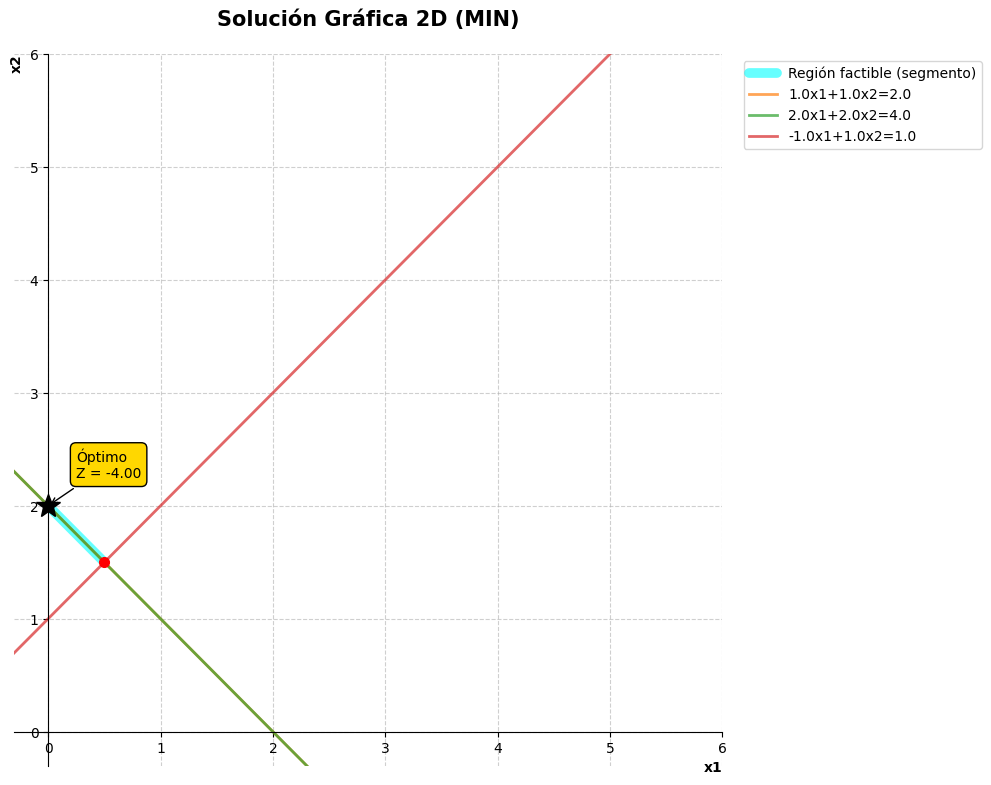

In [2]:
# ==============================================================================
# 3. ZONA DE PRUEBAS PARA EL USUARIO
# ==============================================================================
if __name__ == "__main__":


    texto_ejemplo_tfg = """
    Min x1 - 2x2
    x1 + x2 = 2
    2x1 + 2x2 = 4
    -x1 + x2 >= 1
    x2 <= 3
    """


    resolver_pl_completo(texto_ejemplo_tfg)

  ANALIZANDO LA MATRIZ INICIAL...

--- TABLA INICIAL ---
Base	Z	x1	x2	s1	s2	s3	RHS
Z	  1.00	 -3.00	 -5.00	  0.00	  0.00	  0.00	  0.00
s1	  0.00	  1.00	  0.00	  1.00	  0.00	  0.00	  4.00
s2	  0.00	  0.00	  2.00	  0.00	  1.00	  0.00	 12.00
s3	  0.00	  3.00	  2.00	  0.00	  0.00	  1.00	 18.00
-----------------------------------------------------------------
 PIVOTANDO: Sale [s2] y Entra [x2] | Elemento Pivote: 2.00

--- TABLA FASE II (Iteración) ---
Base	Z	x1	x2	s1	s2	s3	RHS
Z	  1.00	 -3.00	  0.00	  0.00	  2.50	  0.00	 30.00
s1	  0.00	  1.00	  0.00	  1.00	  0.00	  0.00	  4.00
x2	  0.00	  0.00	  1.00	  0.00	  0.50	  0.00	  6.00
s3	  0.00	  3.00	  0.00	  0.00	 -1.00	  1.00	  6.00
-----------------------------------------------------------------
 PIVOTANDO: Sale [s3] y Entra [x1] | Elemento Pivote: 3.00

--- TABLA FASE II (Iteración) ---
Base	Z	x1	x2	s1	s2	s3	RHS
Z	  1.00	  0.00	  0.00	  0.00	  1.50	  1.00	 36.00
s1	  0.00	  0.00	  0.00	  1.00	  0.33	 -0.33	  2.00
x2	  0.00	  0.00	  1.00	  0.

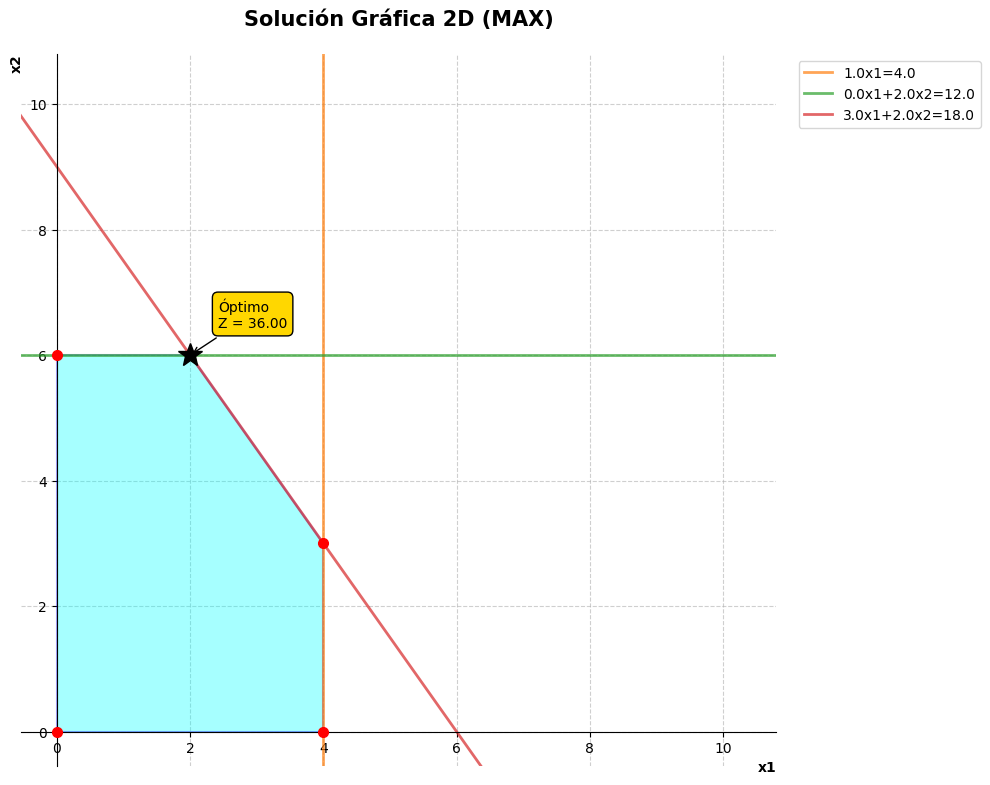


✅ Imagen guardada como 'solucion_grafica_tfg_2.png'


In [9]:
nombres_columnas = ["Z", "x1", "x2", "s1", "s2", "s3", "RHS"]
tabla_inicial = [
    [1, -3.0, -5.0, 0.0, 0.0, 0.0, 0.0],   # Función objetivo (max -> fila 0 en forma -c)
    [0,  1.0,  0.0, 1.0, 0.0, 0.0, 4.0],   # R1: x1 <= 4
    [0,  0.0,  2.0, 0.0, 1.0, 0.0, 12.0],  # R2: 2x2 <= 12
    [0,  3.0,  2.0, 0.0, 0.0, 1.0, 18.0],  # R3: 3x1 + 2x2 <= 18
]

solver = SolucionadorAutonomoPL(tabla_inicial, nombres_columnas, tipo_problema="max")
solver.resolver()

figura = solver.graficar_solucion()
if figura:
    figura.savefig("solucion_grafica_tfg_2.png", dpi=300, bbox_inches="tight", facecolor="white")
    print("\n✅ Imagen guardada como 'solucion_grafica_tfg_2.png'")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13.5)   # más alto para dejar hueco libre encima de la caja azul
ax.axis('off')

def box(x, y, w, h, text, color, fontsize=10.5, subtext=None):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.15",
                        linewidth=1.4, edgecolor='#2c3e50', facecolor=color)
    ax.add_patch(b)
    if subtext:
        ax.text(x+w/2, y+h/2+0.28, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', color='#1c2833')
        ax.text(x+w/2, y+h/2-0.35, subtext, ha='center', va='center', fontsize=8.7, color='#1c2833', style='italic')
    else:
        ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', color='#1c2833')

box(1.0, 9.4, 8.0, 1.9, "Interfaz de usuario (Gradio)", "#aed6f1",
    subtext="gr.Tabs · panel de entrada · botones paso a paso · salida gráfica")
box(1.0, 6.6, 8.0, 1.9, "Traductor de enunciados (Parser)", "#a9dfbf",
    subtext="resolver_pl_completo · expresiones regulares (re) · estandarización")
box(1.0, 3.4, 8.0, 2.5, "Motor de cálculo (Backend)", "#f9e79f",
    subtext="clase SolucionadorAutonomoPL\nPrimal · Dos Fases · Dual · Sensibilidad")
box(1.0, 0.6, 8.0, 2.0, "Renderizado geométrico (Matplotlib)", "#f5b7b1",
    subtext="graficar_solucion · _graficar_2d · _graficar_3d")

def arrow(y1, y2):
    ax.annotate('', xy=(5, y2), xytext=(5, y1),
                arrowprops=dict(arrowstyle='<->', color='#34495e', lw=1.6))

arrow(9.4, 8.5)
arrow(6.6, 5.9)
arrow(3.4, 2.6)

# Título despegado del recuadro azul (antes estaba a y=11.3, justo tocando la caja)
ax.text(5, 12.6, "Arquitectura de la aplicación por capas", ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('arquitectura_capas.png', dpi=200, facecolor='white')
plt.close()

## Interfaz Web

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr
import io
import contextlib
import re

# ====================================================================
# 1. EL MOTOR MATEMÁTICO (Simplex, Linealidad TFG, Sensibilidad y Gráficos)
# ====================================================================
class SolucionadorAutonomoPL:
    def __init__(self, tabla_original, nombres_cols, tipo_problema="min", modo="completo"):
        """
        modo:
          'completo' -> Muestra todo el proceso de golpe, sin pausas.
          'pasos'    -> Además de mostrar todo, guarda cada tabla por separado
                        en self.pasos para poder navegarlas una a una desde Gradio.
          'resumen'  -> Oculta todas las tablas intermedias y solo deja ver
                        el reporte final (análisis y sensibilidad).
        """
        self.tabla = np.array(tabla_original, dtype=float)
        self.tabla_original = np.array(tabla_original, dtype=float)
        self.nombres_cols = nombres_cols[:]
        self.nombres_cols_originales = nombres_cols[:]
        self.tipo_problema = tipo_problema.lower()
        self.num_filas, self.num_cols = self.tabla.shape
        self.vars_basicas = [""] * (self.num_filas - 1)
        self.vars_artificiales = []
        self.f0_original = None
        self.solucion_encontrada = False

        # Rastrea qué filas (restricciones) originales sobreviven tras eliminar redundancias,
        # necesario para reconstruir correctamente B^-1 en el análisis de sensibilidad.
        self.filas_originales_validas = list(range(1, self.num_filas))

        self.modo = modo
        self.solo_resumen = (modo == "resumen")
        self.capturar_pasos = (modo == "pasos")
        self.pasos = []
        self._pivot_pendiente = None

    def log(self, mensaje):
        """Imprime solo si no estamos en modo 'Solo Resumen Final'."""
        if not self.solo_resumen:
            print(mensaje)

    def get_idx_vars(self):
        return [i for i, c in enumerate(self.nombres_cols) if c.lower() not in ['z', 'rhs']]

    def mostrar_tabla(self, titulo=""):
        if self.solo_resumen:
            return

        lineas = [f"\n--- TABLA {titulo} ---"]
        encabezado = "Base\t" + "\t".join(self.nombres_cols)
        lineas.append(encabezado)
        for i in range(self.num_filas):
            base_nombre = "Z" if i == 0 else self.vars_basicas[i-1]
            fila = "\t".join([f"{val:6.2f}" for val in self.tabla[i]])
            lineas.append(f"{base_nombre}\t{fila}")
        lineas.append("-" * 65)
        texto_tabla = "\n".join(lineas)

        print(texto_tabla)

        if self.capturar_pasos:
            if self._pivot_pendiente:
                chunk = self._pivot_pendiente + "\n" + texto_tabla
            else:
                chunk = texto_tabla
            self.pasos.append(chunk)
            self._pivot_pendiente = None

    def diagnosticar_estado(self):
        rhs = self.tabla[1:, -1]
        idx_vars = self.get_idx_vars()
        costos = self.tabla[0, idx_vars]

        es_factible = np.all(rhs >= -1e-5)
        if self.tipo_problema == "max":
            es_optima = np.all(costos >= -1e-5)
        else:
            es_optima = np.all(costos <= 1e-5)
        return es_factible, es_optima

    def pivotar(self, fila, col):
        pivot = self.tabla[fila, col]
        msg = f"🔄 PIVOTANDO: Sale [{self.vars_basicas[fila-1]}] y Entra [{self.nombres_cols[col]}] | Pivote: {pivot:.2f}"
        self.log(msg)
        self._pivot_pendiente = msg
        self.tabla[fila, :] = self.tabla[fila, :] / pivot
        for i in range(self.num_filas):
            if i != fila:
                multiplicador = self.tabla[i, col]
                self.tabla[i, :] -= multiplicador * self.tabla[fila, :]
        self.vars_basicas[fila - 1] = self.nombres_cols[col]

    def preparar_bases_o_dos_fases(self):
        self.log("⚙️  ANALIZANDO LA MATRIZ INICIAL...")
        necesita_dos_fases = False
        filas_sin_base = []

        es_factible, es_optima = self.diagnosticar_estado()
        aplicar_dual = es_optima and not es_factible

        for i in range(1, self.num_filas):
            if self.tabla[i, -1] < 0 and not aplicar_dual:
                self.tabla[i, :] *= -1
                self.log(f"   [!] Fila {i} multiplicada por -1 para recuperar RHS >= 0.")

        idx_vars = self.get_idx_vars()
        for i in range(1, self.num_filas):
            tiene_base = False
            for j in idx_vars:
                columna = self.tabla[1:, j]
                if abs(self.tabla[i, j] - 1.0) < 1e-5 and np.sum(np.abs(columna)) == 1.0:
                    self.vars_basicas[i-1] = self.nombres_cols[j]
                    tiene_base = True
                    break

            if not tiene_base:
                filas_sin_base.append(i)
                necesita_dos_fases = True

        if necesita_dos_fases and aplicar_dual:
             aplicar_dual = False

        if necesita_dos_fases and not aplicar_dual:
            self.log(f"   [!] Faltan variables básicas en las filas: {filas_sin_base}. Iniciando DOS FASES.")
            self.f0_original = self.tabla[0, :].copy()
            num_artificiales = len(filas_sin_base)
            nueva_tabla = np.zeros((self.num_filas, self.num_cols + num_artificiales))
            nueva_tabla[:, :self.num_cols-1] = self.tabla[:, :-1]
            nueva_tabla[:, -1] = self.tabla[:, -1]
            nueva_tabla[0, :] = 0.0

            idx_art = self.num_cols - 1
            for fila_idx in filas_sin_base:
                nombre_art = f"A{fila_idx}"
                self.nombres_cols.insert(idx_art, nombre_art)
                self.vars_artificiales.append(nombre_art)
                self.vars_basicas[fila_idx-1] = nombre_art
                nueva_tabla[fila_idx, idx_art] = 1.0
                nueva_tabla[0, idx_art] = -1.0
                nueva_tabla[0, :] += nueva_tabla[fila_idx, :]
                idx_art += 1

            self.tabla = nueva_tabla
            self.num_cols = self.tabla.shape[1]
            self.tipo_problema_original = self.tipo_problema
            self.tipo_problema = "min"

        return necesita_dos_fases, aplicar_dual

    def iterar_simplex(self, es_fase1=False):
        while True:
            es_factible, es_optima = self.diagnosticar_estado()
            idx_vars = self.get_idx_vars()

            if es_factible and es_optima:
                return True
            elif es_factible and not es_optima:
                costos = self.tabla[0, idx_vars]
                idx_relativo = np.argmin(costos) if self.tipo_problema == "max" else np.argmax(costos)
                col_entrada = idx_vars[idx_relativo]
                ratios = []
                for i in range(1, self.num_filas):
                    coef = self.tabla[i, col_entrada]
                    ratios.append(self.tabla[i, -1] / coef if coef > 1e-5 else np.inf)
                if all(r == np.inf for r in ratios):
                    self.log("⚠️ PROBLEMA NO ACOTADO.")
                    return False
                fila_salida = np.argmin(ratios) + 1
                self.pivotar(fila_salida, col_entrada)
                self.mostrar_tabla("FASE I" if es_fase1 else "FASE II")
            elif not es_factible and es_optima:
                self.log("🌟 Aplicando iteración de SIMPLEX DUAL")
                rhs = self.tabla[1:, -1]
                fila_salida = np.argmin(rhs) + 1
                costos = self.tabla[0, idx_vars]
                coeficientes = self.tabla[fila_salida, idx_vars]
                ratios = []
                for j, coef in enumerate(coeficientes):
                    if coef < -1e-5: ratios.append(abs(costos[j] / coef))
                    else: ratios.append(np.inf)
                if all(r == np.inf for r in ratios):
                    self.log("⚠️ PROBLEMA IMPOSSIBLE (Infactible).")
                    return False
                idx_relativo = np.argmin(ratios)
                col_entrada = idx_vars[idx_relativo]
                self.pivotar(fila_salida, col_entrada)
                self.mostrar_tabla("DUAL SIMPLEX")
            else:
                self.log("⚠️ ESTADO BLOQUEADO.")
                return False

    def transicion_fase_2(self):
        self.log("\n" + "*"*50)
        self.log(" ✅ FASE I COMPLETADA. PREPARANDO FASE II...")
        self.log("*"*50)

        filas_redundantes = []
        for i, var in enumerate(self.vars_basicas):
            if var in self.vars_artificiales: filas_redundantes.append(i + 1)

        # ---- TEORÍA TFG: ANÁLISIS DE LINEALIDAD EN TRANSICIÓN ----
        self.log("\n" + "="*70)
        self.log(" 🔍 ANÁLISIS DE INDEPENDENCIA LINEAL (Teoría Simplex)")
        self.log("="*70)

        if filas_redundantes:
            idx_reales = [j for j, col in enumerate(self.nombres_cols_originales)
                          if not re.match(r'^[se]\d+$', col) and col.lower() not in ['z', 'rhs']]
            idx_reales.append(-1)
            A_espacial = self.tabla_original[1:, idx_reales]

            for i, var in enumerate(self.vars_basicas):
                if var in self.vars_artificiales:
                    try: fila_orig_idx = int(var.replace('A', ''))
                    except ValueError: fila_orig_idx = i + 1

                    self.log(f"\n [!] Detección: La Restricción {fila_orig_idx} es REDUNDANTE.")
                    self.log(f"     Evidencia Simplex: La variable {var} está en la base con valor 0.00.")

                    idx_target = fila_orig_idx - 1
                    filas_otras_idx = [j for j in range(A_espacial.shape[0]) if j != idx_target]

                    if filas_otras_idx:
                        M_otras = A_espacial[filas_otras_idx, :]
                        y_target = A_espacial[idx_target, :]
                        c, _, _, _ = np.linalg.lstsq(M_otras.T, y_target.T, rcond=None)
                        if np.allclose(np.dot(c, M_otras), y_target, atol=1e-4):
                            explicacion = []
                            for j_idx, coef in enumerate(c):
                                if abs(coef) > 1e-4:
                                    n_rest = filas_otras_idx[j_idx] + 1
                                    explicacion.append(f"{coef:.2f} * (Rest. {n_rest})")
                            eq_str = " + ".join(explicacion).replace("+ -", "- ")
                            self.log(f"     Explicación Geométrica: Equivale exactamente a [ {eq_str} ]")

            self.log(f"\n -> Acción del Algoritmo: Eliminando restricciones redundantes de la matriz.")
            self.tabla = np.delete(self.tabla, filas_redundantes, axis=0)
            # Actualizamos el trackeo de filas originales para que B^-1 se calcule bien después
            self.filas_originales_validas = [f for i, f in enumerate(self.filas_originales_validas)
                                              if (i + 1) not in filas_redundantes]
            self.num_filas = self.tabla.shape[0]
            self.vars_basicas = [v for i, v in enumerate(self.vars_basicas) if (i + 1) not in filas_redundantes]
        else:
            self.log(" ✅ Resultado: No se detectó ninguna linealidad/redundancia atrapada.")
        self.log("="*70)
        # ---------------------------------------------------------

        indices_eliminar = [self.nombres_cols.index(v) for v in self.vars_artificiales if v in self.nombres_cols]
        self.tabla = np.delete(self.tabla, indices_eliminar, axis=1)
        self.nombres_cols = [c for c in self.nombres_cols if c not in self.vars_artificiales]
        self.num_cols = self.tabla.shape[1]

        self.tabla[0, :] = 0.0
        for j, nombre in enumerate(self.nombres_cols):
            if nombre in self.nombres_cols_originales:
                idx_orig = self.nombres_cols_originales.index(nombre)
                self.tabla[0, j] = self.f0_original[idx_orig]
        self.tabla[0, -1] = self.f0_original[-1]
        self.tipo_problema = self.tipo_problema_original

        for i in range(1, self.num_filas):
            var_basica = self.vars_basicas[i-1]
            if var_basica in self.nombres_cols:
                col_idx = self.nombres_cols.index(var_basica)
                multiplicador = self.tabla[0, col_idx]
                if abs(multiplicador) > 1e-5:
                    self.tabla[0, :] -= multiplicador * self.tabla[i, :]

    def resolver(self):
        self.log("="*60)
        self.log(" INICIANDO RESOLUCIÓN AUTÓNOMA DEL PROBLEMA")
        self.log("="*60)
        self.solucion_encontrada = False
        necesita_dos_fases, aplicar_dual = self.preparar_bases_o_dos_fases()

        if aplicar_dual:
             self.mostrar_tabla("INICIO DUAL-SIMPLEX")
             exito = self.iterar_simplex()
        else:
            if necesita_dos_fases:
                self.mostrar_tabla("INICIO FASE I")
                exito = self.iterar_simplex(es_fase1=True)
                if not exito: return
                if self.tabla[0, -1] > 1e-5:
                    self.log(f"❌ El problema original es INFACTIBLE (W = {self.tabla[0, -1]:.2f} > 0 en Fase I).")
                    return
                self.transicion_fase_2()

            self.mostrar_tabla("INICIO FASE II" if necesita_dos_fases else "INICIAL")
            exito = self.iterar_simplex(es_fase1=False)

        if exito:
            self.solucion_encontrada = True

    # --------------------------------------------------------------------------
    # ANÁLISIS DE SENSIBILIDAD (B^-1, costes reducidos, precios sombra, rangos)
    # --------------------------------------------------------------------------
    def get_inversa_base(self):
        """Calcula B^-1 directamente usando las columnas originales."""
        num_vars_basicas = len(self.vars_basicas)
        B = np.zeros((num_vars_basicas, num_vars_basicas))
        for j, var in enumerate(self.vars_basicas):
            idx_orig = self.nombres_cols_originales.index(var)
            for local_i, fila_orig in enumerate(self.filas_originales_validas):
                B[local_i, j] = self.tabla_original[fila_orig, idx_orig]
        try:
            return np.linalg.inv(B)
        except np.linalg.LinAlgError:
            return None

    def mostrar_informacion_teorica_final(self):
        if not self.solucion_encontrada:
            return
        print("\n" + "="*70)
        print(" 📊 ANÁLISIS ESTRUCTURAL ÓPTIMO (Teoría Simplex)")
        print("="*70)

        print(f" [1] Base Óptima (B): {self.vars_basicas}")
        solucion_str = []
        for var in self.nombres_cols_originales:
            if var.lower() not in ['z', 'rhs'] and not var.startswith(('s', 'e', 'A')):
                valor = self.tabla[self.vars_basicas.index(var) + 1, -1] if var in self.vars_basicas else 0.0
                solucion_str.append(f"{var} = {valor:.2f}")
        print(f" [2] Punto Óptimo (x*): ( {', '.join(solucion_str)} )")
        print(f" [3] Valor Objetivo (Z*): {self.tabla[0, -1]:.2f}\n")

        B_inv = self.get_inversa_base()
        if B_inv is not None:
            print(" [4] Matriz Inversa de la Base (B^-1):")
            for fila in B_inv:
                print("     | " + "  ".join([f"{val:6.2f}" for val in fila]) + " |")
        else:
            print(" [4] Matriz Inversa de la Base (B^-1): No calculable (Matriz B singular).")

        print("\n [5] Ecuación de Costes Reducidos (Fila 0):")
        ecuacion_z = ["Z"]
        for j, col in enumerate(self.nombres_cols):
            coef = self.tabla[0, j]
            if abs(coef) > 1e-5 and col.lower() != 'rhs':
                signo = "+" if coef > 0 else "-"
                ecuacion_z.append(f"{signo} {abs(coef):.2f}{col}")
        print(f"     {' '.join(ecuacion_z)} = {self.tabla[0, -1]:.2f}")
        print("="*70 + "\n")

    def calcular_rangos_sensibilidad(self):
        if not self.solucion_encontrada:
            return
        print("\n" + "="*80)
        print(" 📈 RANGOS DE TOLERANCIA Y ESTABILIDAD DE LA BASE ÓPTIMA")
        print("="*80)

        num_restricciones = len(self.vars_basicas)
        rhs_actual = self.tabla[1:, -1]
        B_inv = self.get_inversa_base()

        if B_inv is None:
            print(" [!] No es posible calcular rangos de sensibilidad (B^-1 indefinida).")
            return

        print(" [A] Rangos para los Términos Independientes (b_i) [Condición de Factibilidad]:")
        print(f" {'Restricción':<12} | {'Valor Inicial':<15} | {'Valor Mínimo':<15} | {'Valor Máximo':<15}")
        print("-" * 80)
        for local_i, orig_i in enumerate(self.filas_originales_validas):
            b_orig = self.tabla_original[orig_i, -1]
            delta_min, delta_max = -np.inf, np.inf

            for k in range(num_restricciones):
                beta_ki = B_inv[k, local_i]
                b_barra_k = rhs_actual[k]
                if beta_ki > 1e-5:
                    limite = -b_barra_k / beta_ki
                    if limite > delta_min: delta_min = limite
                elif beta_ki < -1e-5:
                    limite = -b_barra_k / beta_ki
                    if limite < delta_max: delta_max = limite

            val_min = b_orig + delta_min if delta_min != -np.inf else -np.inf
            val_max = b_orig + delta_max if delta_max != np.inf else np.inf
            str_min = f"{val_min:.2f}" if val_min != -np.inf else "-Infinito"
            str_max = f"{val_max:.2f}" if val_max != np.inf else "+Infinito"
            print(f" Rest. {orig_i:<6} | {b_orig:<15.2f} | {str_min:<15} | {str_max:<15}")

        print("\n [B] Rangos para los Coeficientes de la Función Objetivo (c_j) [Condición de Optimalidad]:")
        print(f" {'Variable':<12} | {'Coef. Inicial':<15} | {'Valor Mínimo':<15} | {'Valor Máximo':<15}")
        print("-" * 80)
        vars_decision = [c for c in self.nombres_cols_originales if c.startswith('x')]

        for var in vars_decision:
            idx_orig = self.nombres_cols_originales.index(var)
            c_orig = -self.tabla_original[0, idx_orig]
            if var not in self.nombres_cols: continue
            idx_final = self.nombres_cols.index(var)
            cj_barra_actual = self.tabla[0, idx_final]

            if var not in self.vars_basicas:
                if self.tipo_problema == "max":
                    val_min, val_max = -np.inf, c_orig + cj_barra_actual
                else:
                    val_min, val_max = c_orig + cj_barra_actual, np.inf
            else:
                fila_basica = self.vars_basicas.index(var) + 1
                delta_min, delta_max = -np.inf, np.inf

                for j_col, nom_col in enumerate(self.nombres_cols):
                    if nom_col.lower() in ['z', 'rhs'] or nom_col in self.vars_basicas: continue
                    alpha_kj = self.tabla[fila_basica, j_col]
                    T0j = self.tabla[0, j_col]

                    if abs(alpha_kj) > 1e-5:
                        limite = -T0j / alpha_kj
                        if self.tipo_problema == "max":
                            if alpha_kj > 1e-5:
                                if limite > delta_min: delta_min = limite
                            else:
                                if limite < delta_max: delta_max = limite
                        else:
                            if alpha_kj > 1e-5:
                                if limite < delta_max: delta_max = limite
                            else:
                                if limite > delta_min: delta_min = limite

                val_min = c_orig + delta_min if delta_min != -np.inf else -np.inf
                val_max = c_orig + delta_max if delta_max != np.inf else np.inf

            str_min = f"{val_min:.2f}" if val_min != -np.inf else "-Infinito"
            str_max = f"{val_max:.2f}" if val_max != np.inf else "+Infinito"
            print(f" {var:<12} | {c_orig:<15.2f} | {str_min:<15} | {str_max:<15}")
        print("="*80 + "\n")

    # --------------------------------------------------------------------------
    # MÓDULOS DE GRÁFICO
    # --------------------------------------------------------------------------
    def graficar_solucion(self):
        if not self.solucion_encontrada:
            return None
        vars_decision = [c for c in self.nombres_cols_originales if c.startswith('x')]
        if len(vars_decision) == 2:
            return self._graficar_2d(vars_decision)
        elif len(vars_decision) == 3:
            return self._graficar_3d(vars_decision)
        return None

    def _graficar_2d(self, vars_decision):
        idx_x1 = self.nombres_cols_originales.index(vars_decision[0])
        idx_x2 = self.nombres_cols_originales.index(vars_decision[1])

        def es_punto_factible(px, py):
            if px < -1e-4 or py < -1e-4: return False
            for i in range(1, self.num_filas):
                a, b, c = self.tabla_original[i, idx_x1], self.tabla_original[i, idx_x2], self.tabla_original[i, -1]
                valor = a * px + b * py
                es_menor_igual, es_mayor_igual = False, False
                for j in range(self.num_cols - 1):
                    if j in [idx_x1, idx_x2]: continue
                    coef = self.tabla_original[i, j]
                    if coef > 1e-5: es_menor_igual = True
                    elif coef < -1e-5: es_mayor_igual = True
                if es_mayor_igual and not es_menor_igual:
                    if valor < c - 1e-4: return False
                elif es_menor_igual and not es_mayor_igual:
                    if valor > c + 1e-4: return False
                elif not es_mayor_igual and not es_menor_igual:
                    if abs(valor - c) > 1e-4: return False
            return True

        rectas = [(1, 0, 0), (0, 1, 0)]
        for i in range(1, self.num_filas):
            a, b, c = self.tabla_original[i, idx_x1], self.tabla_original[i, idx_x2], self.tabla_original[i, -1]
            if abs(a) > 1e-5 or abs(b) > 1e-5: rectas.append((a, b, c))

        puntos_corte = []
        for i in range(len(rectas)):
            for j in range(i+1, len(rectas)):
                a1, b1, c1 = rectas[i]
                a2, b2, c2 = rectas[j]
                det = a1*b2 - a2*b1
                if abs(det) > 1e-5: puntos_corte.append(((c1*b2 - c2*b1)/det, (a1*c2 - a2*c1)/det))

        soluciones = {var: self.tabla[i+1, -1] for i, var in enumerate(self.vars_basicas)}
        opt_x = soluciones.get(vars_decision[0], 0)
        opt_y = soluciones.get(vars_decision[1], 0)

        puntos_q1 = [(px, py) for px, py in puntos_corte if px >= -1e-2 and py >= -1e-2]
        if not puntos_q1: max_x, max_y = opt_x + 5, opt_y + 5
        else:
             max_x = max([p[0] for p in puntos_q1] + [opt_x, 5]) * 1.2
             max_y = max([p[1] for p in puntos_q1] + [opt_y, 5]) * 1.2
        max_val = max(max_x, max_y)

        rectas_cierre = rectas + [(1, 0, max_val*1.5), (0, 1, max_val*1.5)]
        puntos_corte_ext = []
        for i in range(len(rectas_cierre)):
            for j in range(i+1, len(rectas_cierre)):
                a1, b1, c1 = rectas_cierre[i]
                a2, b2, c2 = rectas_cierre[j]
                det = a1*b2 - a2*b1
                if abs(det) > 1e-5: puntos_corte_ext.append(((c1*b2 - c2*b1)/det, (a1*c2 - a2*c1)/det))

        vertices_factibles = []
        for px, py in puntos_corte_ext:
            if px <= max_val*1.5 + 1e-3 and py <= max_val*1.5 + 1e-3:
                if es_punto_factible(px, py):
                    if not any(abs(px - vx) < 1e-4 and abs(py - vy) < 1e-4 for vx, vy in vertices_factibles):
                        vertices_factibles.append((px, py))

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.set_xlim(-max_val*0.05, max_val)
        ax.set_ylim(-max_val*0.05, max_val)

        if len(vertices_factibles) >= 3:
            cx = sum(p[0] for p in vertices_factibles) / len(vertices_factibles)
            cy = sum(p[1] for p in vertices_factibles) / len(vertices_factibles)
            vertices_factibles.sort(key=lambda p: np.arctan2(p[1] - cy, p[0] - cx))
            ax.add_patch(plt.Polygon(vertices_factibles, closed=True, facecolor='cyan', alpha=0.3, edgecolor='blue', lw=1.5))

        vx_reales = [p[0] for p in vertices_factibles if p[0] < max_val*1.4 and p[1] < max_val*1.4]
        vy_reales = [p[1] for p in vertices_factibles if p[0] < max_val*1.4 and p[1] < max_val*1.4]
        ax.plot(vx_reales, vy_reales, 'ro', markersize=7, zorder=4)

        x_vals = np.linspace(-max_val*0.1, max_val*1.2, 400)
        colores = plt.cm.tab10.colors
        for i in range(1, self.num_filas):
            a, b, c = self.tabla_original[i, idx_x1], self.tabla_original[i, idx_x2], self.tabla_original[i, -1]
            if abs(a) < 1e-5 and abs(b) < 1e-5: continue
            color = colores[i % len(colores)]
            if abs(b) > 1e-5: ax.plot(x_vals, (c - a * x_vals) / b, color=color, label=f'{a}x1+{b}x2={c}', lw=2, alpha=0.7)
            else: ax.axvline(x=c/a, color=color, label=f'{a}x1={c}', lw=2, alpha=0.7)

        ax.plot(opt_x, opt_y, 'k*', markersize=18, zorder=6)
        ax.annotate(f'Óptimo\nZ = {self.tabla[0, -1]:.2f}', (opt_x, opt_y), textcoords="offset points", xytext=(20, 20),
                    bbox=dict(boxstyle="round,pad=0.4", fc="gold", ec="black"), arrowprops=dict(arrowstyle="->"))
        ax.set_xlabel(vars_decision[0], loc='right', fontweight='bold')
        ax.set_ylabel(vars_decision[1], loc='top', fontweight='bold')
        ax.set_title(f"Solución Gráfica 2D ({self.tipo_problema.upper()})", fontsize=15, fontweight='bold', pad=20)
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        return fig

    def _graficar_3d(self, vars_decision):
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        soluciones = {var: self.tabla[i+1, -1] for i, var in enumerate(self.vars_basicas)}
        opt_x = soluciones.get(vars_decision[0], 0)
        opt_y = soluciones.get(vars_decision[1], 0)
        opt_z = soluciones.get(vars_decision[2], 0)
        max_val = max(opt_x, opt_y, opt_z, 5) * 1.5

        idx_x1 = self.nombres_cols_originales.index(vars_decision[0])
        idx_x2 = self.nombres_cols_originales.index(vars_decision[1])
        idx_x3 = self.nombres_cols_originales.index(vars_decision[2])
        colores = plt.cm.Set2.colors

        for i in range(1, self.num_filas):
            a, b = self.tabla_original[i, idx_x1], self.tabla_original[i, idx_x2]
            c, d = self.tabla_original[i, idx_x3], self.tabla_original[i, -1]
            color = colores[i % len(colores)]
            if abs(a) < 1e-5 and abs(b) < 1e-5 and abs(c) < 1e-5: continue

            if abs(c) > 1e-5:
                xx, yy = np.meshgrid(np.linspace(0, max_val, 10), np.linspace(0, max_val, 10))
                zz = (d - a * xx - b * yy) / c
                zz[zz < 0] = np.nan
                ax.plot_surface(xx, yy, zz, alpha=0.4, color=color, edgecolor='none')
            elif abs(b) > 1e-5:
                xx, zz = np.meshgrid(np.linspace(0, max_val, 10), np.linspace(0, max_val, 10))
                yy = (d - a * xx) / b
                yy[yy < 0] = np.nan
                ax.plot_surface(xx, yy, zz, alpha=0.4, color=color, edgecolor='none')
            elif abs(a) > 1e-5:
                yy, zz = np.meshgrid(np.linspace(0, max_val, 10), np.linspace(0, max_val, 10))
                xx = d / a * np.ones_like(yy)
                xx[xx < 0] = np.nan
                ax.plot_surface(xx, yy, zz, alpha=0.4, color=color, edgecolor='none')

        ax.scatter(opt_x, opt_y, opt_z, color='red', s=150, edgecolors='black', label='Punto Óptimo', zorder=10)
        ax.text(opt_x, opt_y, opt_z + max_val*0.08, f'Z = {self.tabla[0, -1]:.2f}',
                color='black', fontsize=12, fontweight='bold', ha='center',
                bbox=dict(facecolor='yellow', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))

        ax.set_xlabel(vars_decision[0], fontweight='bold')
        ax.set_ylabel(vars_decision[1], fontweight='bold')
        ax.set_zlabel(vars_decision[2], fontweight='bold')
        ax.set_title(f"Espacio Tridimensional ({self.tipo_problema.upper()})", fontsize=14, fontweight='bold')
        ax.set_xlim(0, max_val)
        ax.set_ylim(0, max_val)
        ax.set_zlim(0, max_val)
        plt.legend(loc='upper right')
        return fig


# ====================================================================
# 2. FUNCIÓN PUENTE: TEXTO -> SOLUCIONADOR
# ====================================================================

def resolver_desde_texto(texto_modelo, opcion_linealidad_str, opcion_visual_str):
    """
    Devuelve: (texto_consola, figura, lista_pasos, indice_inicial, reporte_final, texto_label_paso)
    """
    opcion_linealidad = '1' if 'Inicio' in opcion_linealidad_str else '2'

    if opcion_visual_str.startswith('2'):
        modo = 'pasos'
    elif opcion_visual_str.startswith('3'):
        modo = 'resumen'
    else:
        modo = 'completo'

    consola_virtual = io.StringIO()
    figura = None
    pasos_lista = []
    reporte_final = ""

    if not texto_modelo or texto_modelo.strip() == "":
        return "❌ Error: El cuadro de texto está vacío.", None, [], 1, "", ""

    with contextlib.redirect_stdout(consola_virtual):
        try:
            lineas = [linea.strip() for linea in texto_modelo.strip().split('\n') if linea.strip()]
            objetivo_str = lineas[0]
            restricciones_strs = lineas[1:]

            tipo_problema = "min" if objetivo_str.lower().startswith("min") else "max"
            obj_expr = re.sub(r'^(min|max)\s*', '', objetivo_str, flags=re.IGNORECASE)

            def extraer_terminos(expresion):
                expresion = expresion.replace(" ", "")
                if not expresion.startswith(('+', '-')): expresion = '+' + expresion
                terminos = re.findall(r'([+-])(\d*\.?\d*)([a-zA-Z_]\w*)', expresion)
                dict_coefs = {}
                for signo, coef_str, var in terminos:
                    coef = 1.0 if coef_str == "" else float(coef_str)
                    if signo == "-": coef = -coef
                    dict_coefs[var] = dict_coefs.get(var, 0.0) + coef
                return dict_coefs

            coefs_obj = extraer_terminos(obj_expr)
            vars_decision = set(coefs_obj.keys())

            restricciones_parseadas = []
            for r_str in restricciones_strs:
                if "<=" in r_str: signo = "<="; lhs, rhs = r_str.split("<=")
                elif ">=" in r_str: signo = ">="; lhs, rhs = r_str.split(">=")
                elif "=" in r_str: signo = "="; lhs, rhs = r_str.split("=")
                else: continue

                coefs_lhs = extraer_terminos(lhs)
                vars_decision.update(coefs_lhs.keys())
                restricciones_parseadas.append({"coefs": coefs_lhs, "signo": signo, "rhs": float(rhs.strip())})

            vars_decision = sorted(list(vars_decision))
            nombres_cols = vars_decision.copy()

            # ---- PRE-PROCESAMIENTO (OPCIÓN 1) CON REPORTE MATEMÁTICO ----
            if opcion_linealidad == '1':
                if modo != 'resumen':
                    print("="*70)
                    print(" 🔍 PRE-PROCESAMIENTO: ANÁLISIS GEOMÉTRICO AL INICIO")
                    print("="*70)
                A_temp = np.zeros((len(restricciones_parseadas), len(vars_decision) + 1))
                for i, r in enumerate(restricciones_parseadas):
                    for j, var in enumerate(vars_decision):
                        A_temp[i, j] = r["coefs"].get(var, 0.0)
                    A_temp[i, -1] = r["rhs"]

                filas_independientes, restricciones_limpias = [], []
                for i in range(A_temp.shape[0]):
                    y_target = A_temp[i, :]
                    es_redundante = False
                    if len(filas_independientes) > 0:
                        M_otras = A_temp[filas_independientes, :]
                        c, _, _, _ = np.linalg.lstsq(M_otras.T, y_target.T, rcond=None)
                        if np.allclose(np.dot(c, M_otras), y_target, atol=1e-4):
                            es_redundante = True
                            explicacion = []
                            for j_idx, coef in enumerate(c):
                                if abs(coef) > 1e-4:
                                    n_rest = filas_independientes[j_idx] + 1
                                    explicacion.append(f"{coef:.2f} * (Rest. {n_rest})")
                            eq_str = " + ".join(explicacion).replace("+ -", "- ")
                            if modo != 'resumen':
                                print(f" [!] Detección temprana: La Restricción {i+1} es REDUNDANTE.")
                                print(f"     Demostración: Equivale exactamente a [ {eq_str} ]")
                    if not es_redundante:
                        filas_independientes.append(i)
                        restricciones_limpias.append(restricciones_parseadas[i])

                if len(restricciones_limpias) < len(restricciones_parseadas):
                    if modo != 'resumen':
                        print("\n -> Acción: Limpiando la redundancia antes de armar la matriz Simplex.\n")
                    restricciones_parseadas = restricciones_limpias
                elif modo != 'resumen':
                    print(" ✅ No se detectó redundancia. El modelo está limpio.\n")

            # Asignación de variables de holgura/exceso
            idx_s, idx_e = 1, 1
            for r in restricciones_parseadas:
                if r["signo"] == "<=":
                    nombre_s = f"s{idx_s}"; nombres_cols.append(nombre_s)
                    r["var_holgura"] = (nombre_s, 1.0); idx_s += 1
                elif r["signo"] == ">=":
                    nombre_e = f"e{idx_e}"; nombres_cols.append(nombre_e)
                    r["var_holgura"] = (nombre_e, -1.0); idx_e += 1
                else:
                    r["var_holgura"] = None

            nombres_cols.append("RHS")
            tabla = np.zeros((len(restricciones_parseadas) + 1, len(nombres_cols)))

            for var, coef in coefs_obj.items():
                tabla[0, nombres_cols.index(var)] = -coef

            for i, r in enumerate(restricciones_parseadas):
                fila = i + 1
                for var, coef in r["coefs"].items():
                    tabla[fila, nombres_cols.index(var)] = coef
                if r["var_holgura"]:
                    tabla[fila, nombres_cols.index(r["var_holgura"][0])] = r["var_holgura"][1]
                tabla[fila, -1] = r["rhs"]

            solver = SolucionadorAutonomoPL(tabla.tolist(), nombres_cols, tipo_problema=tipo_problema, modo=modo)
            solver.resolver()

            # REPORTE UNIFICADO + ANÁLISIS DE SENSIBILIDAD (siempre se muestra, en cualquier modo)
            if solver.solucion_encontrada:
                print("\n" + "="*70)
                print(" 📊 REPORTE GLOBAL UNIFICADO (Análisis de Sensibilidad)")
                print("="*70)
                print(f" Valor Óptimo Definitivo de Z: {solver.tabla[0, -1]:.2f}\n")
                print(f" {'Variable':<10} | {'Valor Final':<15} | {'Análisis Fila 0':<35}")
                print("-" * 70)
                for var in solver.nombres_cols_originales:
                    if var.lower() in ['z', 'rhs']: continue
                    valor_final = solver.tabla[solver.vars_basicas.index(var) + 1, -1] if var in solver.vars_basicas else 0.0
                    analisis_fila_0 = solver.tabla[0, solver.nombres_cols.index(var)] if var in solver.nombres_cols else 0.0

                    if var.startswith('x'): texto_analisis = f"Reduced Cost: {analisis_fila_0:>8.2f}"
                    elif var.startswith('s') or var.startswith('e'): texto_analisis = f"Dual Price:   {analisis_fila_0:>8.2f}"
                    else: texto_analisis = f"Artificial (Eliminada)"
                    print(f" {var:<10} | {valor_final:<15.2f} | {texto_analisis:<35}")
                print("="*70 + "\n")

                solver.mostrar_informacion_teorica_final()
                solver.calcular_rangos_sensibilidad()

                figura = solver.graficar_solucion()

            pasos_lista = solver.pasos

        except Exception as e:
            print(f"\n❌ ERROR INTERNO:\nNo se pudo procesar el texto. Revisa la sintaxis.\nDetalle: {str(e)}")

    texto_completo = consola_virtual.getvalue()

    # Aislamos el bloque del reporte final (para poder mostrarlo al llegar al último paso)
    lineas_completas = texto_completo.split("\n")
    idx_reporte = None
    for idx, linea in enumerate(lineas_completas):
        if "REPORTE GLOBAL UNIFICADO" in linea:
            idx_reporte = max(0, idx - 1)
            break
    if idx_reporte is not None:
        reporte_final = "\n".join(lineas_completas[idx_reporte:])

    if modo == 'pasos':
        if pasos_lista:
            if len(pasos_lista) == 1:
                # Con un único paso, ya estamos en el "final": se muestra todo de una vez.
                texto_mostrado = pasos_lista[0] + (("\n\n" + reporte_final) if reporte_final else "")
            else:
                texto_mostrado = pasos_lista[0]
            label = f"Paso 1 de {len(pasos_lista)}"
        else:
            texto_mostrado = texto_completo
            label = ""
        return texto_mostrado, figura, pasos_lista, 1, reporte_final, label
    else:
        # 'completo' y 'resumen' se muestran enteros de una sola vez, como antes.
        return texto_completo, figura, [], 1, "", ""


def _render_paso(pasos, indice, reporte_final):
    """indice es 1-based: 1..len(pasos). Al llegar al último, se concatena TODO el desarrollo."""
    total = len(pasos)
    if indice >= total:
        texto = "\n\n".join(pasos)
        if reporte_final:
            texto += "\n\n" + reporte_final
        label = f"Paso {total} de {total} (desarrollo completo)"
    else:
        texto = pasos[indice - 1]
        label = f"Paso {indice} de {total}"
    return texto, label


def avanzar_paso(pasos, indice, reporte_final):
    if not pasos:
        return "(La navegación por pasos solo está disponible en el modo 'Paso a Paso'. Vuelve a resolver seleccionando ese modo.)", indice, ""
    nuevo_indice = min(indice + 1, len(pasos))
    texto, label = _render_paso(pasos, nuevo_indice, reporte_final)
    return texto, nuevo_indice, label


def retroceder_paso(pasos, indice, reporte_final):
    if not pasos:
        return "(La navegación por pasos solo está disponible en el modo 'Paso a Paso'. Vuelve a resolver seleccionando ese modo.)", indice, ""
    nuevo_indice = max(indice - 1, 1)
    texto, label = _render_paso(pasos, nuevo_indice, reporte_final)
    return texto, nuevo_indice, label


def toggle_navegacion(opcion_visual_str):
    return gr.update(visible=opcion_visual_str.startswith('2'))


# ====================================================================
# 3. DISEÑO DE LA APLICACIÓN WEB (GRADIO)
# ====================================================================

with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🚀 Optimizador Simplex Autónomo - TFG")
    gr.Markdown("Resuelve problemas de Programación Lineal con Detección Automática de Linealidad (Redundancia) y Análisis de Sensibilidad.")

    # Estados para la navegación paso a paso
    pasos_state = gr.State([])
    indice_state = gr.State(1)
    reporte_final_state = gr.State("")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("Escribe el problema usando texto normal. Usa `x1`, `x2`, etc.")

            texto_input = gr.Textbox(
                label="Modelo Matemático",
                lines=6,
                value="Min x1 - 2x2\nx1 + x2 = 2\n2x1 + 2x2 = 4\n-x1 + x2 >= 1\nx2 <= 3"
            )

            opcion_lin = gr.Radio(
                choices=["1. Detección al Inicio (Geometría)", "2. Detección en Transición (Simplex)"],
                value="1. Detección al Inicio (Geometría)",
                label="¿Cuándo eliminar redundancias matemáticas? (TFG)"
            )

            opcion_visual = gr.Radio(
                choices=["1. Todo Completo (sin pausas)", "2. Paso a Paso (Interactivo)", "3. Solo Resumen Final"],
                value="1. Todo Completo (sin pausas)",
                label="Nivel de detalle de la resolución"
            )

            btn_resolver_txt = gr.Button("⚙️ Resolver Problema", variant="primary")

        # -----------------------------------
        # SECCIÓN DERECHA: RESULTADOS GLOBALES
        # -----------------------------------
        with gr.Column(scale=1):
            gr.Markdown("## 📊 Resultados y Desarrollo")
            grafico_salida = gr.Plot(label="Representación Gráfica")

            with gr.Row(visible=False) as fila_navegacion:
                btn_anterior = gr.Button("⬅️ Paso Anterior")
                label_paso = gr.Markdown("")
                btn_siguiente = gr.Button("Paso Siguiente ➡️")

            consola_salida = gr.Textbox(label="Desarrollo del Algoritmo", lines=25, max_lines=40)

    btn_resolver_txt.click(
        fn=resolver_desde_texto,
        inputs=[texto_input, opcion_lin, opcion_visual],
        outputs=[consola_salida, grafico_salida, pasos_state, indice_state, reporte_final_state, label_paso]
    )

    opcion_visual.change(
        fn=toggle_navegacion,
        inputs=opcion_visual,
        outputs=fila_navegacion
    )

    btn_siguiente.click(
        fn=avanzar_paso,
        inputs=[pasos_state, indice_state, reporte_final_state],
        outputs=[consola_salida, indice_state, label_paso]
    )

    btn_anterior.click(
        fn=retroceder_paso,
        inputs=[pasos_state, indice_state, reporte_final_state],
        outputs=[consola_salida, indice_state, label_paso]
    )

app.launch(share=True)

/tmp/ipykernel_987/3593494788.py:829: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca402ce59dc0afa18e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
